In [47]:
import numpy as np
import matplotlib.pyplot as plt
import glob
import os

# Use the current working directory since __file__ is not defined in some environments (like Jupyter)
base_dir = os.getcwd()

# Define the folder path where normalized metrics files are stored relative to the current directory
norm_metrics_folder_path = os.path.join(base_dir, "dataset", "norm_metrics_files")
metrics_folder_path = os.path.join(base_dir, "dataset", "metrics_files")
norm_metric_file_pattern = os.path.join(norm_metrics_folder_path, "norm_metrics_*.npy")
metric_file_pattern = os.path.join(metrics_folder_path, "metrics_*.npy")

# Retrieve a sorted list of file paths based on the index in the filename
norm_metric_files = sorted(glob.glob(norm_metric_file_pattern), key=lambda x: int(os.path.basename(x).split('_')[2].split('.')[0]))

# Retrieve a sorted list of file paths based on the index in the filename
metric_files = sorted(glob.glob(metric_file_pattern), key=lambda x: int(os.path.basename(x).split('_')[1].split('.')[0]))

# Print out how many files exist
print(f"Found {len(metric_files)} metrics files.")

# Initialize a list to hold the normalized metrics
norm_metrics = []
metrics = []

# Loop over the files and load each file's metrics
for file in norm_metric_files:
    metric = np.load(file)
    norm_metrics.append(metric)

for file in metric_files:
    metric = np.load(file)
    metrics.append(metric)

# Convert the list to a numpy array of shape (300, 5)
norm_metrics = np.array(norm_metrics)
metrics = np.array(metrics)

Found 300 metrics files.


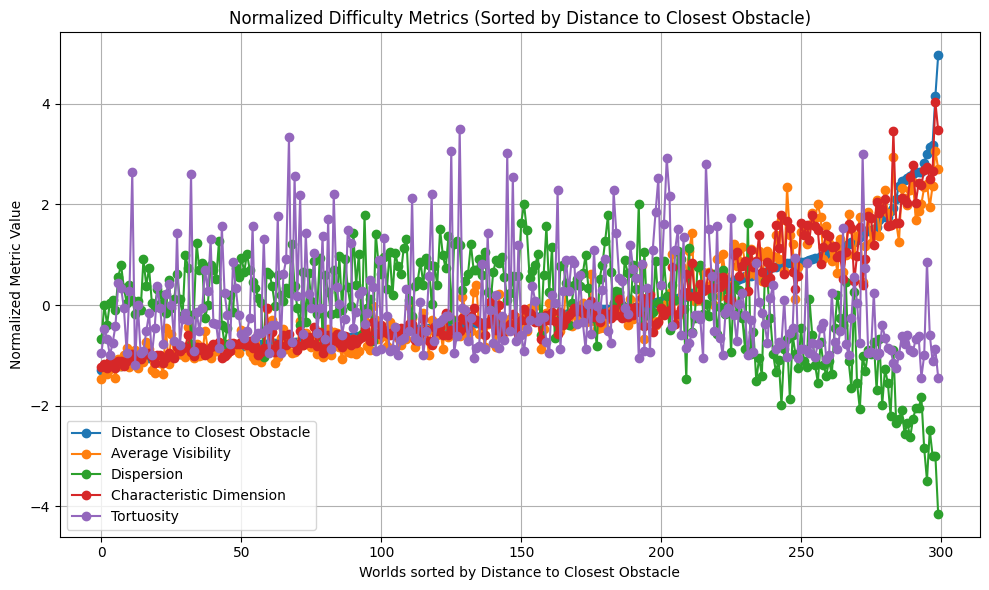

In [48]:
# Sort the worlds by the "Distance to Closest Obstacle" metric (first column)
# (Assuming that a lower distance indicates higher difficulty)
sort_order = np.argsort(norm_metrics[:, 0])  # Ascending order (lowest distance first)
norm_metrics_sorted = norm_metrics[sort_order]

# Define the metric names as provided in the README
metrics_names = [
    "Distance to Closest Obstacle",
    "Average Visibility",
    "Dispersion",
    "Characteristic Dimension",
    "Tortuosity"
]

# Create an index array for the sorted worlds
sorted_indexes = np.arange(norm_metrics_sorted.shape[0])

# Plot the normalized metrics across worlds sorted by distance to closest obstacle
plt.figure(figsize=(10, 6))
for i in range(norm_metrics_sorted.shape[1]):
    plt.plot(sorted_indexes, norm_metrics_sorted[:, i], marker='o', linestyle='-', label=metrics_names[i])

plt.xlabel("Worlds sorted by Distance to Closest Obstacle")
plt.ylabel("Normalized Metric Value")
plt.title("Normalized Difficulty Metrics (Sorted by Distance to Closest Obstacle)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

['Distance to Closest Obstacle', 'Average Visibility', 'Dispersion', 'Characteristic Dimension', 'Tortuosity']


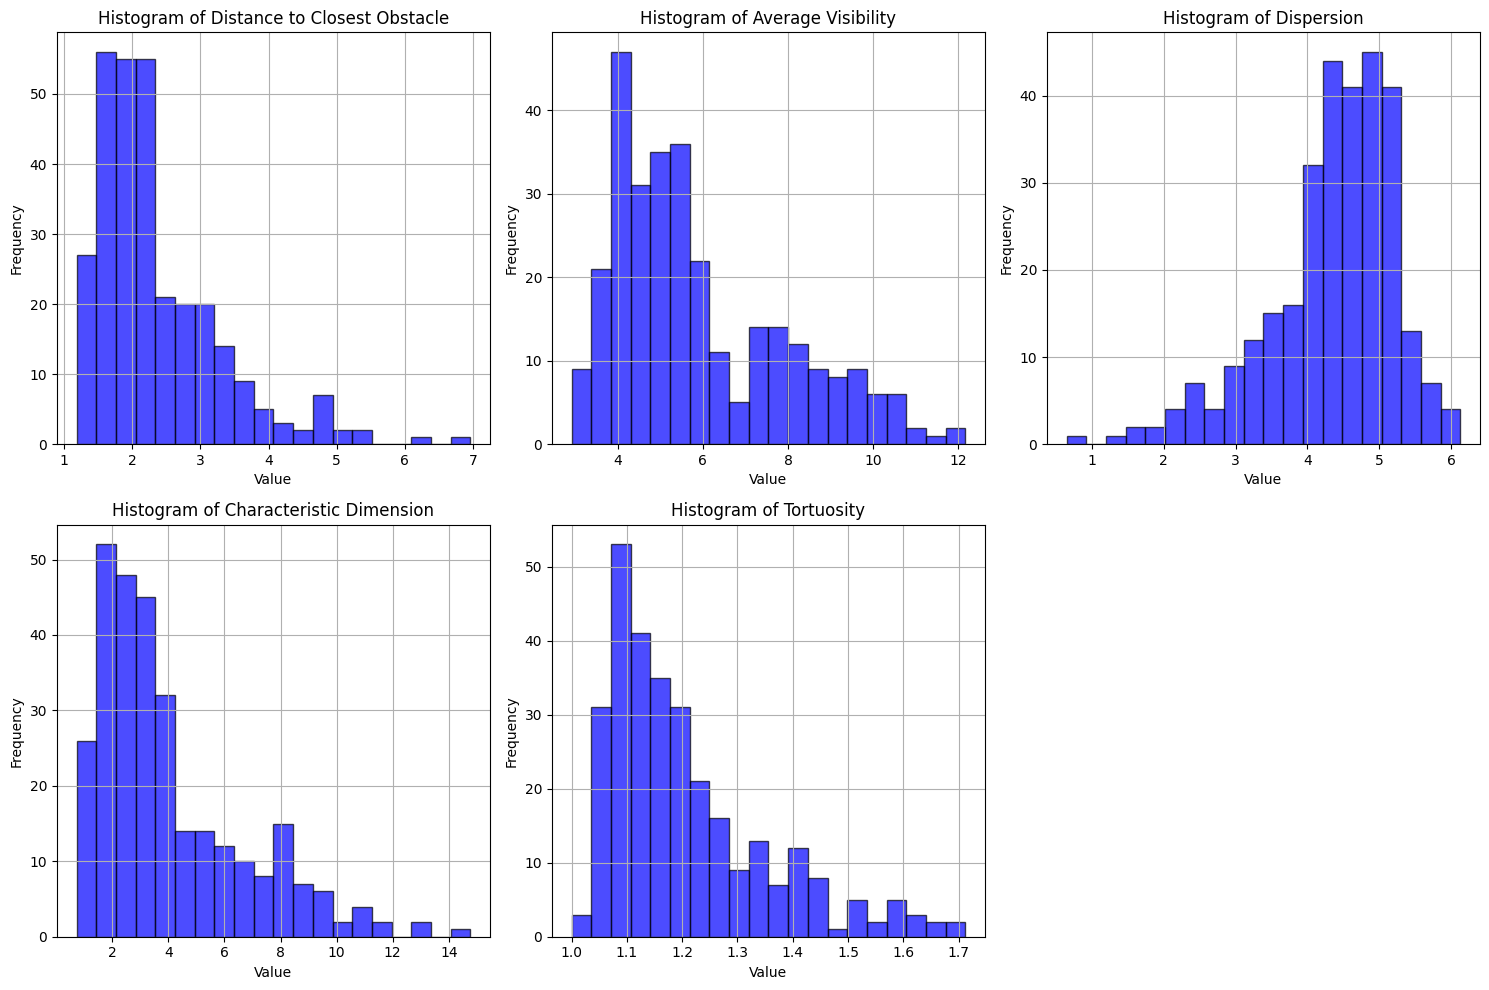

In [49]:
# Generate histograms for each metric
plt.figure(figsize=(15, 10))

for i, metric_name in enumerate(metrics_names):
    plt.subplot(2, 3, i + 1)  # Create a subplot grid (2 rows, 3 columns)
    plt.hist(metrics[:, i], bins=20, alpha=0.7, color='blue', edgecolor='black')
    plt.title(f"Histogram of {metric_name}")
    plt.xlabel("Value")
    plt.ylabel("Frequency")
    plt.grid(True)
print(metrics_names)
plt.tight_layout()
plt.show()

In [50]:
import random
selected_indices = []

for file in metric_files:
    metrics = np.load(file)
    if metrics[2] < 3.5 and metrics[3] < 8:
        # Extract the index from the filename (e.g., 'norm_metrics_23.npy' -> 23)
        idx = int(os.path.basename(file).split('_')[1].split('.')[0])
        selected_indices.append(idx)

# Print out the number of files satisfying the conditions
print("Number of files with Dispersion < 4 and Characteristic Dimension < 6:", len(selected_indices))

Number of files with Dispersion < 4 and Characteristic Dimension < 6: 18


Randomly sampled indices: [252, 167, 122, 209, 63]


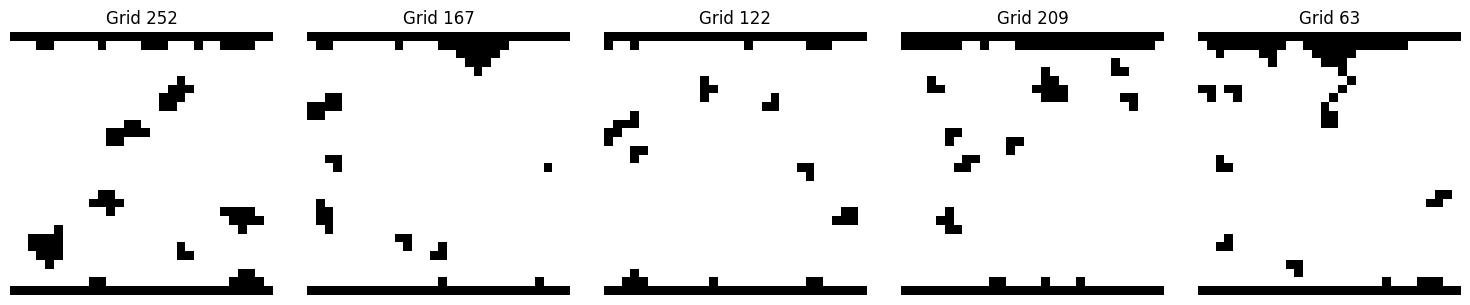

In [51]:
# Randomly sample 5 indices from the selected indices (if there are at least 5)
sampled_indices = random.sample(selected_indices, 5) if len(selected_indices) >= 5 else selected_indices
print("Randomly sampled indices:", sampled_indices)

# ---------------------------
# Part 2: Plot the corresponding grid files
# ---------------------------

# Define the folder path for grid files
grid_folder = os.path.join(base_dir, "dataset", "grid_files")

# Create a subplot with one column per sampled index
fig, axes = plt.subplots(1, len(sampled_indices), figsize=(15, 3))
grids = []

# Loop over each sampled index, load the corresponding grid file, and plot it.
for ax, idx in zip(axes, sampled_indices):
    grid_path = os.path.join(grid_folder, f"grid_{idx}.npy")
    grid = np.load(grid_path)
    grids.append(grid)
    ax.imshow(grid, cmap="gray_r", origin="upper")
    ax.set_title(f"Grid {idx}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [52]:
# 2. Function to extract islands (connected filled cells) via BFS.
from collections import defaultdict, deque

def pad_and_fill_grid(grid, pad_lr=10):
    """
    Pads the grid with pad_lr columns on the left and right, then fills the border of the new grid with obstacles.
    
    Parameters:
        grid (np.array): The original occupancy grid (boolean array).
        pad_lr (int): Number of columns to add to both the left and right sides.
        
    Returns:
        np.array: The new padded grid with its border cells set to True (obstacles).
    """
    # Pad left and right with False (empty) cells.
    # No padding is done to the top and bottom here.
    padded_grid = np.pad(grid, ((0, 0), (pad_lr, pad_lr)), mode='constant', constant_values=False)
    
    # Now, fill the outer border of the padded grid with obstacles (True).
    padded_grid[0, :] = True           # Top row
    padded_grid[-1, :] = True          # Bottom row
    padded_grid[:, 0] = True           # Leftmost column
    padded_grid[:, -1] = True          # Rightmost column
    
    return padded_grid

# NEW: Pre-process the grid by filling in any square that is immediately surrounded on all four sides.
def pre_process_island(grid):
    rows, cols = grid.shape
    to_fill = []
    # Only consider cells that are not on the border of the grid.
    for r in range(1, rows - 1):
        for c in range(1, cols - 1):
            if not grid[r, c]:
                # Check if the four immediate neighbors are obstacles.
                if grid[r - 1, c] and grid[r + 1, c] and grid[r, c - 1] and grid[r, c + 1]:
                    to_fill.append((r, c))
    # Fill the cells after scanning.
    for r, c in to_fill:
        grid[r, c] = True
    return grid

def get_islands(grid):
    islands = []
    visited = np.zeros_like(grid, dtype=bool)
    rows, cols = grid.shape
    for r in range(rows):
        for c in range(cols):
            if grid[r, c] and not visited[r, c]:
                island = []
                queue = deque([(r, c)])
                visited[r, c] = True
                while queue:
                    rr, cc = queue.popleft()
                    island.append((rr, cc))
                    for dr, dc in [(1,0), (-1,0), (0,1), (0,-1)]:
                        nr, nc = rr + dr, cc + dc
                        if 0 <= nr < rows and 0 <= nc < cols:
                            if grid[nr, nc] and not visited[nr, nc]:
                                visited[nr, nc] = True
                                queue.append((nr, nc))
                islands.append(island)
    return islands

islands = get_islands(grid)

# 3. For each cell in an island, determine its border edges.
def get_border_edges(island, grid):
    border_edges = []
    rows, cols = grid.shape
    for (r, c) in island:
        # Check top edge: if at top of grid or neighbor above is free.
        if r == 0 or not grid[r-1, c]:
            border_edges.append((r, c, 'top'))
        # Check bottom edge.
        if r == rows - 1 or not grid[r+1, c]:
            border_edges.append((r, c, 'bottom'))
        # Check left edge.
        if c == 0 or not grid[r, c-1]:
            border_edges.append((r, c, 'left'))
        # Check right edge.
        if c == cols - 1 or not grid[r, c+1]:
            border_edges.append((r, c, 'right'))
    return border_edges

# 4. Merge contiguous border edges into line segments.
def merge_edges(border_edges):
    segments = []
    # We use dictionaries to group edges by orientation and the constant coordinate.
    # For horizontal edges (top and bottom) the y coordinate is constant.
    horizontal_edges = defaultdict(list)  # key: (orientation, y) ; value: list of starting column positions
    # For vertical edges (left and right) the x coordinate is constant.
    vertical_edges = defaultdict(list)      # key: (orientation, x) ; value: list of starting row positions

    for (r, c, side) in border_edges:
        if side == 'top':
            # Top edge lies at y = r from x=c to x=c+1.
            horizontal_edges[('top', r)].append(c)
        elif side == 'bottom':
            # Bottom edge lies at y = r+1.
            horizontal_edges[('bottom', r+1)].append(c)
        elif side == 'left':
            # Left edge lies at x = c from y=r to y=r+1.
            vertical_edges[('left', c)].append(r)
        elif side == 'right':
            # Right edge lies at x = c+1.
            vertical_edges[('right', c+1)].append(r)

    # Merge horizontal edges.
    for key, col_list in horizontal_edges.items():
        orientation, y = key
        col_list.sort()
        start = col_list[0]
        end = start
        for col in col_list[1:]:
            if col == end + 1:
                end = col
            else:
                # A segment goes from (start, y) to (end+1, y)
                segments.append(((start, y), (end+1, y)))
                start = col
                end = col
        segments.append(((start, y), (end+1, y)))

    # Merge vertical edges.
    for key, row_list in vertical_edges.items():
        orientation, x = key
        row_list.sort()
        start = row_list[0]
        end = start
        for row in row_list[1:]:
            if row == end + 1:
                end = row
            else:
                segments.append(((x, start), (x, end+1)))
                start = row
                end = row
        segments.append(((x, start), (x, end+1)))
    
    return segments

def get_segments(grid):
    grid = pad_and_fill_grid(grid)
    islands = get_islands(grid)
    final_segments = []
    for island in islands:
        border_edges = get_border_edges(island, grid)
        segments = merge_edges(border_edges)
        final_segments.extend(segments)
    return final_segments

11
[((0, 0), (50, 0)), ((1, 1), (11, 1)), ((20, 1), (22, 1)), ((34, 1), (49, 1)), ((11, 2), (12, 2)), ((13, 2), (17, 2)), ((19, 2), (20, 2)), ((22, 2), (23, 2)), ((28, 2), (34, 2)), ((12, 3), (13, 3)), ((17, 3), (18, 3)), ((23, 3), (24, 3)), ((27, 3), (28, 3)), ((18, 4), (19, 4)), ((24, 4), (26, 4)), ((0, 30), (50, 30)), ((1, 29), (31, 29)), ((32, 29), (35, 29)), ((38, 29), (49, 29)), ((26, 5), (27, 5)), ((31, 28), (32, 28)), ((35, 28), (38, 28)), ((0, 0), (0, 30)), ((1, 1), (1, 29)), ((11, 1), (11, 2)), ((12, 2), (12, 3)), ((13, 2), (13, 3)), ((17, 2), (17, 3)), ((19, 2), (19, 4)), ((20, 1), (20, 2)), ((18, 3), (18, 4)), ((22, 1), (22, 2)), ((23, 2), (23, 3)), ((24, 3), (24, 4)), ((27, 3), (27, 5)), ((28, 2), (28, 3)), ((26, 4), (26, 5)), ((34, 1), (34, 2)), ((50, 0), (50, 30)), ((49, 1), (49, 29)), ((31, 28), (31, 29)), ((32, 28), (32, 29)), ((35, 28), (35, 29)), ((38, 28), (38, 29)), ((27, 5), (28, 5)), ((27, 6), (28, 6)), ((27, 5), (27, 6)), ((28, 5), (28, 6)), ((10, 6), (12, 6)), 

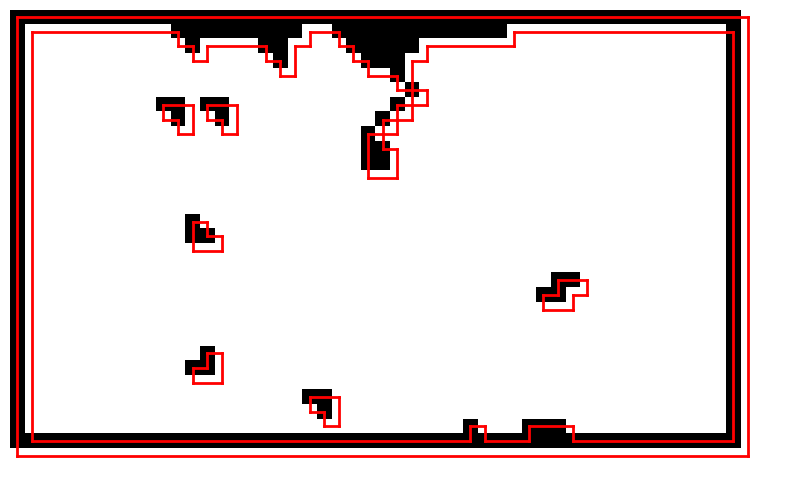

In [53]:


grid_segments = []
segment_list = []
grid = grids[4]
grid = pad_and_fill_grid(grid, pad_lr=10)
grid = pre_process_island(grid)
islands = get_islands(grid)
print(len(islands))
for island in islands:
    border_edges = get_border_edges(island, grid)
    segments = merge_edges(border_edges)
    segment_list.extend(segments)

print(segment_list)

# plot all segments
plt.figure(figsize=(10, 10))
grids[4] = pad_and_fill_grid(grids[4], pad_lr=10)
plt.imshow(grids[4], cmap="gray_r", origin="upper")
for (x1, y1), (x2, y2) in segment_list:
    plt.plot([x1, x2], [y1, y2], color='red', linewidth=2)
plt.axis("off")
plt.show()


In [ ]:

# Define the resolution (0.2 units per grid cell)
import yaml


def write_world_yaml(filepath, segment_list):
    # Define the resolution (0.2 units per grid cell)
    resolution = 0.2

    # Create the obstacle list by scaling the coordinates of each segment.
    obstacle_list = []
    for seg in segment_list:
        (x1, y1), (x2, y2) = seg
        vertex1 = [x1 * resolution, y1 * resolution]
        vertex2 = [x2 * resolution, y2 * resolution]
        obstacle_list.append({
            "shape": {"name": "linestring", "vertices": [vertex1, vertex2]},
            "state": [0, 0, 0]
        })

    # Build the complete YAML structure.
    data = {
        "world": {
            "height": 6,  # the height of the world
            "width": 10,   # the width of the world
            "step_time": 0.1,  # the time step of the simulation
            "sample_time": 0.1,  # the sample time of the simulation
            "show_sensor": False
        },
        "robot": [
            {
                "state": [9, 3, -3.14],
                "goal": [1, 3, -3.14],
                "kinematics": {"name": "diff"},
                "shape": {"name": "circle", "radius": 0.2},
                "vel_min": [-1.5, -1.5],
                "vel_max": [1.5, 1.5],
                "color": "royalblue",
                "arrive_mode": "position",
                "goal_threshold": 0.2
            }
        ],
        "obstacle": obstacle_list
    }

    # Write the YAML data to a file.
    with open(filepath, "w") as f:
        yaml.dump(data, f)




In [55]:
selected_grids = []
print(len(selected_indices))
# Loop over each sampled index, load the corresponding grid file, and plot it.
for idx in selected_indices:
    grid_path = os.path.join(grid_folder, f"grid_{idx}.npy")
    grid = np.load(grid_path)
    selected_grids.append(grid)

print(len(selected_grids))

world_dataset_folder = os.path.join(base_dir, "world_dataset")
os.makedirs(world_dataset_folder, exist_ok=False)

for i, grid in enumerate(selected_grids):
    segment_list = get_segments(grid)
    file_path = os.path.join(world_dataset_folder, f"world_{i}.yaml")
    write_world_yaml(file_path, segment_list)


18
18
